In [1]:
 # 1.Explorarea setului de date

from sklearn.datasets import load_iris
iris = load_iris()

X = iris.data

print("Numarul de exemple: ", X.shape[0])
print("Dimensiunea caracteristicilor: ", X.shape[1])
print("Denumirea coloanelor(atributelor): ",iris.feature_names)
print("Numele claselor: ",iris.target_names)

Numarul de exemple:  150
Dimensiunea caracteristicilor:  4
Denumirea coloanelor(atributelor):  ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Numele claselor:  ['setosa' 'versicolor' 'virginica']


In [2]:
 # 2.Impartirea setului in date de antrenament si testare

from sklearn.model_selection import train_test_split

y=iris.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


print("----- Dimensiuni subseturi -----")

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

----- Dimensiuni subseturi -----
X_train shape: (120, 4)
X_test shape: (30, 4)
y_train shape: (120,)
y_test shape: (30,)


In [3]:
 # 3.Preprocesarea datelor

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("*** Inainte de scalare ***")
print(X_train[:3])

print("*** Dupa scalare ***")
print(X_train_scaled[:3])


*** Inainte de scalare ***
[[4.6 3.6 1.  0.2]
 [5.7 4.4 1.5 0.4]
 [6.7 3.1 4.4 1.4]]
*** Dupa scalare ***
[[-1.47393679  1.20365799 -1.56253475 -1.31260282]
 [-0.13307079  2.99237573 -1.27600637 -1.04563275]
 [ 1.08589829  0.08570939  0.38585821  0.28921757]]


In [7]:
 # 4.Construirea si antrenarea modelului KNN

from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=3)

knn.fit(X_train_scaled, y_train)
accuracy = knn.score(X_test_scaled, y_test)

print("Acuratețea modelului este:", accuracy)

Acuratețea modelului este: 1.0


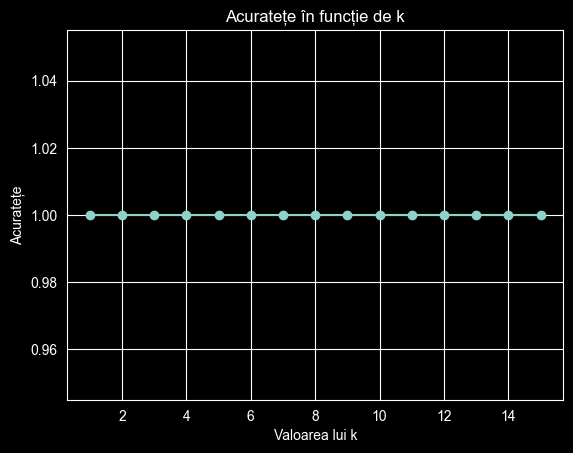

In [4]:
 # 5.Explorarea impactului valorii k

from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt

k_values = range(1, 16)
accuracies = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_scaled, y_train)

    acc = model.score(X_test_scaled, y_test)
    accuracies.append(acc)

plt.plot(k_values, accuracies, marker='o')
plt.xlabel("Valoarea lui k")
plt.ylabel("Acuratețe")
plt.title("Acuratețe în funcție de k")
plt.show()

In [9]:
 # 6.Evaluarea impactului valorii k

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

y_pred = knn.predict(X_test_scaled)

cm = confusion_matrix(y_test, y_pred)

print("Matricea de confuzie:")
print(cm)


print("Raport de clasificare:")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

Matricea de confuzie:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
Raport de clasificare:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



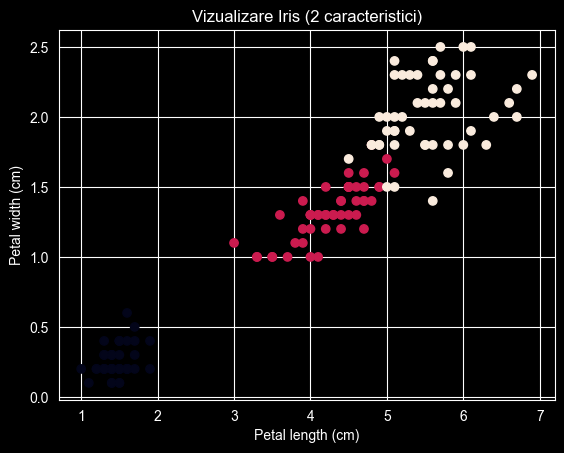

In [10]:
 # 7. Vizualizarea datelor
import matplotlib.pyplot as plt

X_2d = iris.data[:, 2:4]
y = iris.target

plt.figure()

plt.scatter(X_2d[:, 0], X_2d[:, 1], c=y)

plt.xlabel("Petal length (cm)")
plt.ylabel("Petal width (cm)")
plt.title("Vizualizare Iris (2 caracteristici)")

plt.show()


In [18]:
 # Predictie Floare noua
lungime_sepala = float(input("Lungimea sepalei(cm) : "))
latimea_sepala = float(input("Latimea sepalei(cm): "))
lungimea_petala = float(input("Lungimea petalei (cm): "))
latimea_petala = float(input("Latimea petalei (cm): "))

noua_floare = [[lungime_sepala,latimea_sepala,lungimea_petala],lungimea_petala,latimea_petala]

noua_floare_scalata = scaler.transform(noua_floare)

prediction = knn.predict(noua_floare_scalata)

print("Floarea este de tip:", iris.target_names[prediction][0])

Floarea este de tip: virginica
